# Week 7: TrashNet Classification using DenseNet121

## Objective

The objective of this notebook is to compare DenseNet121 with EfficientNetB0 on the TrashNet dataset using the same preprocessing, data augmentation, feature extraction, and fine-tuning pipeline.

The workflow includes:

- Loading the TrashNet dataset
- Applying data augmentation
- Building a DenseNet121 transfer learning model
- Performing feature extraction
- Fine-tuning the model
- Evaluating model performance
- Comparing results with EfficientNetB0

Dataset: TrashNet

Classes:
- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [6]:
class_names = train_dataset.class_names

print("Classes:")

for i, name in enumerate(class_names):
    print(i, "-", name)

Classes:
0 - cardboard
1 - glass
2 - metal
3 - paper
4 - plastic
5 - trash


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [9]:
base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("DenseNet121 loaded successfully!")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
DenseNet121 loaded successfully!


In [10]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.densenet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,043,654 (26.87 MB)

 Trainable params: 6,150 (24.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

In [13]:
history_feature = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 736s 11s/step - accuracy: 0.4570 - loss: 1.4778 - val_accuracy: 0.6772 - val_loss: 0.8859 - learning_rate: 0.0010
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 226ms/step - accuracy: 0.6622 - loss: 0.9140 - val_accuracy: 0.7802 - val_loss: 0.6644 - learning_rate: 0.0010
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - accuracy: 0.7275 - loss: 0.7553 - val_accuracy: 0.7881 - val_loss: 0.5815 - learning_rate: 0.0010
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - accuracy: 0.7488 - loss: 0.6786 - val_accuracy: 0.8257 - val_loss: 0.5209 - learning_rate: 0.0010
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - accuracy: 0.7799 - loss: 0.6272 - val_accuracy: 0.8277 - val_loss: 0.5059 - learning_rate: 0.0010
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.7997 - loss: 0.5760 - val_accuracy: 0.8297 - val_loss: 0.4900 - learning_rate: 0.0010
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.8002 - loss: 0.5

In [15]:
print(f"Best Validation Accuracy: {max(history_feature.history['val_accuracy']) * 100:.2f}%")

Best Validation Accuracy: 84.36%


In [16]:
# Final Training and Validation Accuracy

train_acc = history_feature.history["accuracy"][-1]
val_acc = history_feature.history["val_accuracy"][-1]

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

Training Accuracy: 82.69%
Validation Accuracy: 83.76%


In [17]:
model.save("/content/drive/MyDrive/trashnet_densenet_feature_extraction.keras")

print("Feature extraction model saved successfully!")

Feature extraction model saved successfully!


In [18]:
base_model.trainable = True

# Freeze all layers except the final 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

trainable_count = sum(layer.trainable for layer in base_model.layers)

print("Trainable DenseNet121 layers:", trainable_count)

Trainable DenseNet121 layers: 30


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [20]:
fine_tune_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [21]:
history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[
        fine_tune_early_stop,
        fine_tune_reduce_lr
    ]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 362ms/step - accuracy: 0.7770 - loss: 0.6392 - val_accuracy: 0.8396 - val_loss: 0.4461 - learning_rate: 1.0000e-05
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 226ms/step - accuracy: 0.7898 - loss: 0.5903 - val_accuracy: 0.8436 - val_loss: 0.4443 - learning_rate: 1.0000e-05
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step - accuracy: 0.7928 - loss: 0.5693 - val_accuracy: 0.8396 - val_loss: 0.4405 - learning_rate: 1.0000e-05
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 240ms/step - accuracy: 0.8056 - loss: 0.5353 - val_accuracy: 0.8495 - val_loss: 0.4343 - learning_rate: 1.0000e-05
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 230ms/step - accuracy: 0.8071 - loss: 0.5523 - val_accuracy: 0.8515 - val_loss: 0.4273 - learning_rate: 1.0000e-05
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 226ms/step - accuracy: 0.7982 - loss: 0.5371 - val_accuracy: 0.8515 - val_loss: 0.4196 - learning_rate: 1.0000e-05
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - acc

In [22]:
final_train_acc = history_finetune.history["accuracy"][-1]
final_val_acc = history_finetune.history["val_accuracy"][-1]
best_val_acc = max(history_finetune.history["val_accuracy"])

print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")

Final Training Accuracy: 83.53%
Final Validation Accuracy: 86.34%
Best Validation Accuracy: 86.34%


In [23]:
val_loss, val_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print(f"Restored Best Validation Loss: {val_loss:.4f}")
print(f"Restored Best Validation Accuracy: {val_accuracy * 100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.8634 - loss: 0.3886
Restored Best Validation Loss: 0.3886
Restored Best Validation Accuracy: 86.34%


In [24]:
model.save(
    "/content/drive/MyDrive/trashnet_densenet121_finetuned.keras"
)

model.save_weights(
    "/content/drive/MyDrive/trashnet_densenet121_finetuned.weights.h5"
)

print("DenseNet121 fine-tuned model and weights saved successfully.")

DenseNet121 fine-tuned model and weights saved successfully.


| Stage              | Training Accuracy | Validation Accuracy |
| ------------------ | ----------------: | ------------------: |
| Feature extraction |            82.69% |         84.36% best |
| Fine-tuning        |            83.53% |          **86.34%** |
Fine-tuning improved DenseNet121 by about 1.98 percentage points, so the fine-tuning pipeline worked.

However, your current backbone comparison is:
| Backbone                              | Best Validation Accuracy |
| ------------------------------------- | -----------------------: |
| **EfficientNetB0 feature extraction** |               **88.12%** |
| DenseNet121 fine-tuned                |                   86.34% |
| EfficientNetB0 fine-tuned             |                   85.74% |


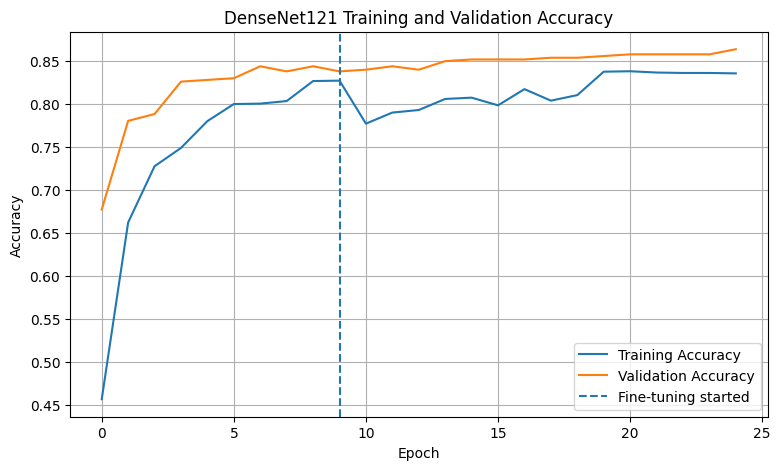

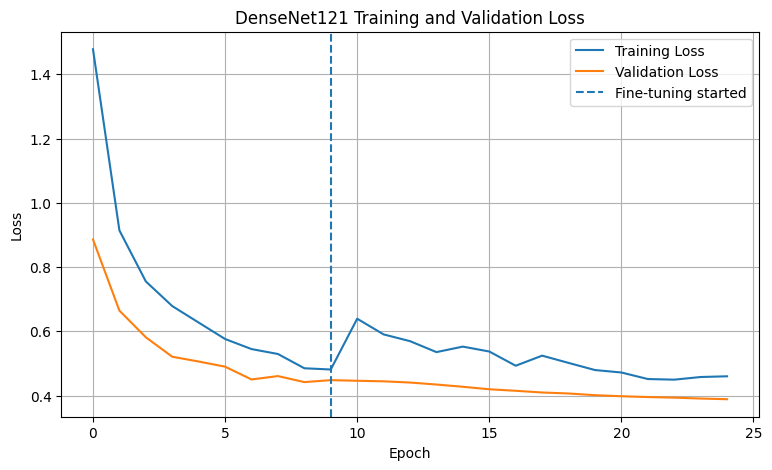

In [25]:
import matplotlib.pyplot as plt

feature_acc = history_feature.history["accuracy"]
feature_val_acc = history_feature.history["val_accuracy"]
feature_loss = history_feature.history["loss"]
feature_val_loss = history_feature.history["val_loss"]

finetune_acc = history_finetune.history["accuracy"]
finetune_val_acc = history_finetune.history["val_accuracy"]
finetune_loss = history_finetune.history["loss"]
finetune_val_loss = history_finetune.history["val_loss"]

all_acc = feature_acc + finetune_acc
all_val_acc = feature_val_acc + finetune_val_acc
all_loss = feature_loss + finetune_loss
all_val_loss = feature_val_loss + finetune_val_loss

fine_tune_start = len(feature_acc)

plt.figure(figsize=(9, 5))
plt.plot(all_acc, label="Training Accuracy")
plt.plot(all_val_acc, label="Validation Accuracy")
plt.axvline(
    fine_tune_start - 1,
    linestyle="--",
    label="Fine-tuning started"
)
plt.title("DenseNet121 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(all_loss, label="Training Loss")
plt.plot(all_val_loss, label="Validation Loss")
plt.axvline(
    fine_tune_start - 1,
    linestyle="--",
    label="Fine-tuning started"
)
plt.title("DenseNet121 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
import numpy as np

true_labels = []
predicted_labels = []

for images, labels in validation_dataset:
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    true_labels.extend(labels.numpy())
    predicted_labels.extend(predictions)

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

print("Predictions completed.")
print("Validation samples:", len(true_labels))

Predictions completed.
Validation samples: 505


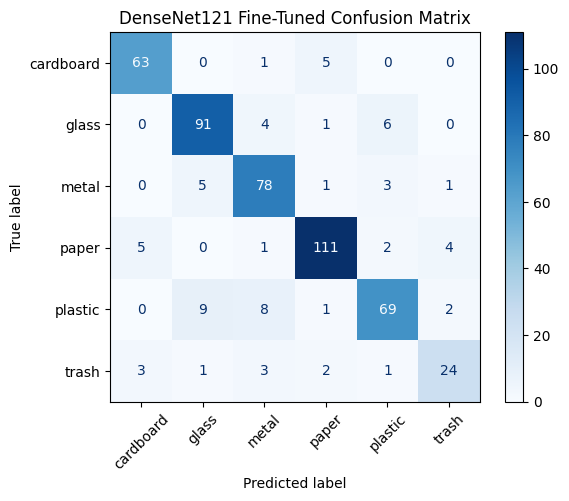

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("DenseNet121 Fine-Tuned Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=2
    )
)

              precision    recall  f1-score   support

   cardboard       0.89      0.91      0.90        69
       glass       0.86      0.89      0.88       102
       metal       0.82      0.89      0.85        88
       paper       0.92      0.90      0.91       123
     plastic       0.85      0.78      0.81        89
       trash       0.77      0.71      0.74        34

    accuracy                           0.86       505
   macro avg       0.85      0.85      0.85       505
weighted avg       0.86      0.86      0.86       505



In [29]:
confusion_pairs = []

for true_index in range(len(class_names)):
    for predicted_index in range(len(class_names)):
        if true_index != predicted_index and cm[true_index, predicted_index] > 0:
            confusion_pairs.append(
                (
                    class_names[true_index],
                    class_names[predicted_index],
                    int(cm[true_index, predicted_index])
                )
            )

confusion_pairs = sorted(
    confusion_pairs,
    key=lambda item: item[2],
    reverse=True
)

print("Top confusion pairs:")

for true_name, predicted_name, count in confusion_pairs[:3]:
    print(f"{true_name} → {predicted_name}: {count}")

Top confusion pairs:
plastic → glass: 9
plastic → metal: 8
glass → plastic: 6


# Conclusion

DenseNet121 was evaluated as an alternative backbone for the TrashNet image classification task using the same training pipeline as EfficientNetB0.

After feature extraction and fine-tuning, the model achieved a validation accuracy of **86.34%**. The confusion matrix and classification report showed strong performance across most waste categories, with the most common confusion pairs being Plastic → Glass, Plastic → Metal, and Glass → Plastic. These errors were primarily caused by similarities in appearance, transparency, and reflective surfaces.

## Backbone Comparison

| Backbone | Validation Accuracy |
|-----------|--------------------:|
| EfficientNetB0 | **88.12%** |
| DenseNet121 | **86.34%** |

Although DenseNet121 performed well, EfficientNetB0 achieved a higher validation accuracy on the TrashNet dataset and was selected as the final backbone for future experiments. Testing multiple backbone architectures confirmed that the training pipeline was reliable and provided confidence in selecting the most suitable model for this dataset.